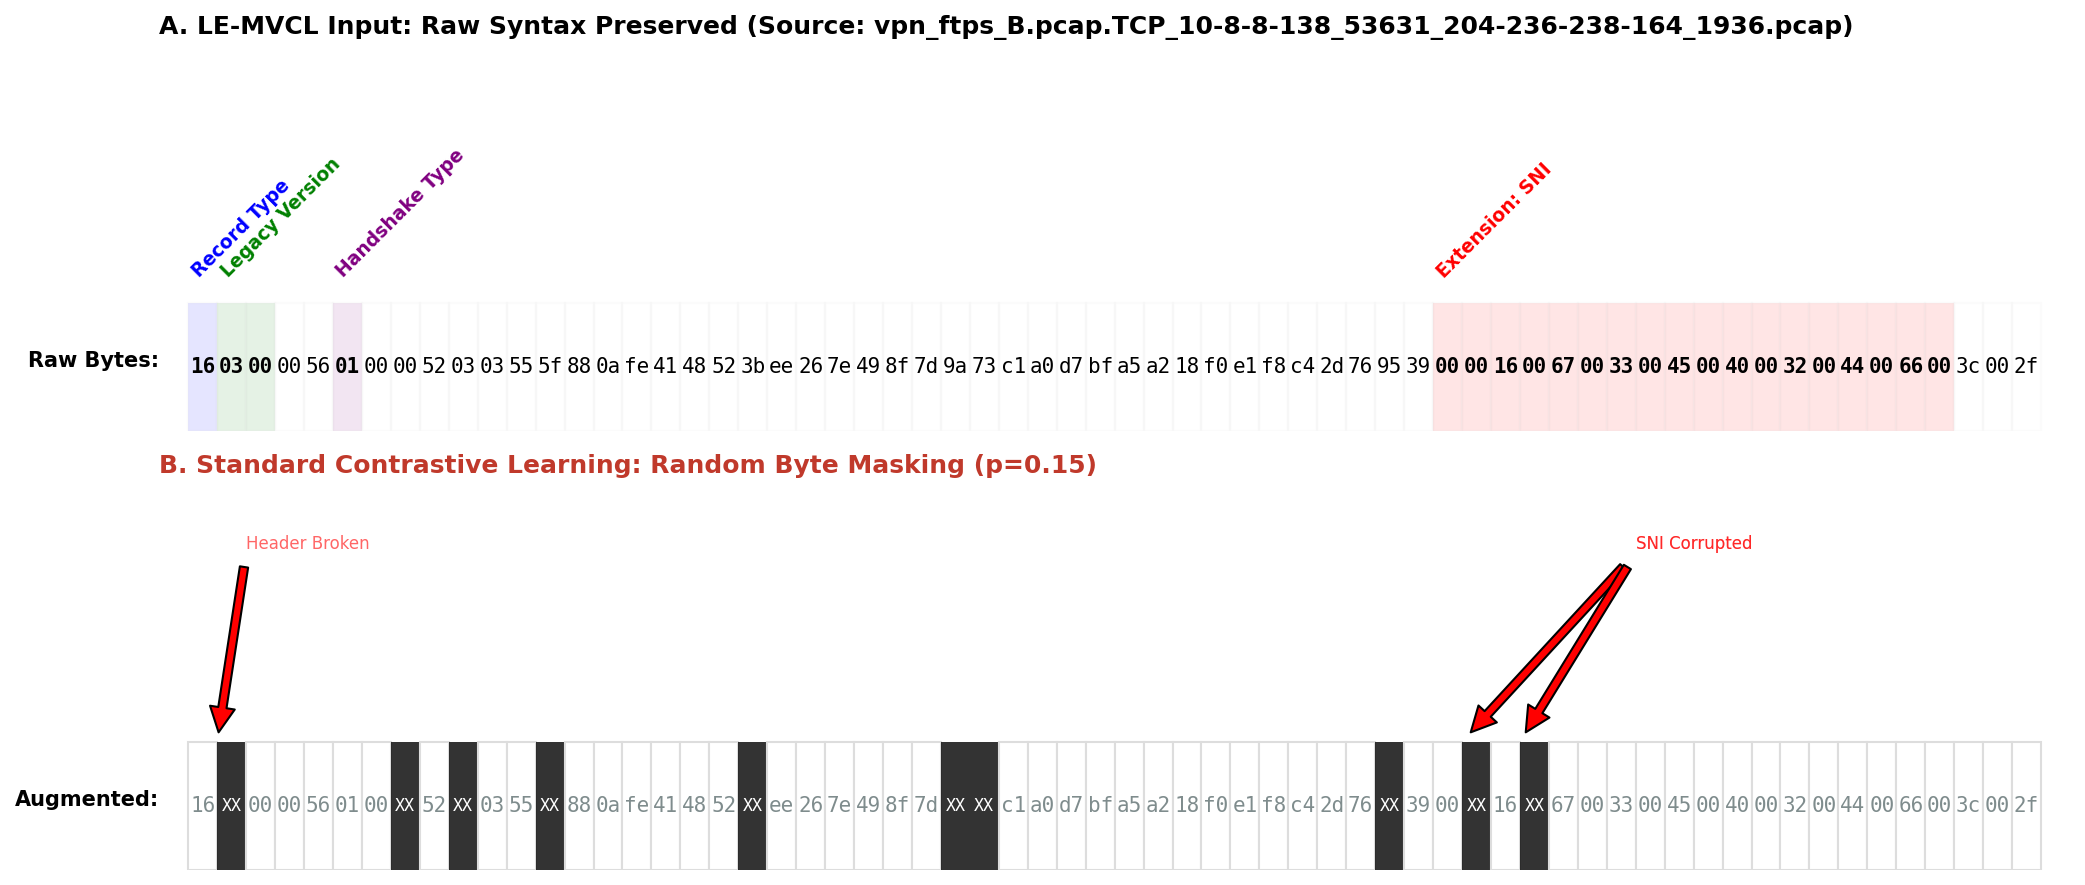

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scapy.all import rdpcap, TCP, UDP, Raw
import binascii

# --- CONFIGURATION ---
# Use the path from your Alpha#1 notebook
SOURCE_DIR = "/content/drive/MyDrive/1 Skripsi/Notebook/VPNOnlyDataset"

def get_real_tls_payload(source_dir):
    """Finds a real TLS Client Hello packet from the dataset."""
    if not os.path.exists(source_dir):
        print("Source directory not found. Using fallback mock data.")
        return None, "Mock_File.pcap"

    pcap_files = [f for f in os.listdir(source_dir) if f.endswith('.pcap')]
    random.shuffle(pcap_files)

    for pcap in pcap_files[:10]: # Check first 10 random files
        try:
            path = os.path.join(source_dir, pcap)
            packets = rdpcap(path, count=20) # Read first 20 packets

            for pkt in packets:
                if TCP in pkt and Raw in pkt:
                    payload = bytes(pkt[Raw])
                    # Check for TLS Handshake (0x16) and Client Hello (0x01)
                    # This ensures we visualize the "Delicate Syntax"
                    if len(payload) > 40 and payload[0] == 0x16 and payload[5] == 0x01:
                        return payload, pcap
        except:
            continue

    print("No TLS Client Hello found in sample. Returning random payload.")
    return None, None

def visualize_real_destruction():
    # 1. Get Real Data
    payload, filename = get_real_tls_payload(SOURCE_DIR)

    # Convert to Hex List for Plotting
    hex_data = [f"{b:02x}" for b in payload[:64]] # First 64 bytes

    # 2. Setup Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150)
    plt.subplots_adjust(hspace=0.5)

    # --- Define Syntax Regions (TLS 1.2/1.3 Logic) ---
    # These offsets are standard for TLS Client Hello
    regions = [
        (0, 0, "Record Type", "blue"),     # 16 (Handshake)
        (1, 2, "Legacy Version", "green"), # 03 01 (TLS 1.0 compat)
        (5, 5, "Handshake Type", "purple"),# 01 (Client Hello)
        (43, 60, "Extension: SNI", "red")  # Server Name (variable loc, approx for viz)
    ]

    # --- PLOT A: ORIGINAL (LE-MVCL View) ---
    ax = axes[0]
    ax.set_title(f"A. LE-MVCL Input: Raw Syntax Preserved (Source: {filename})",
                 loc='left', fontweight='bold', fontsize=12)
    ax.axis('off')

    for i, byte in enumerate(hex_data):
        row = 0
        col = i

        # Color Syntax
        color = 'white'
        font_weight = 'normal'
        for start, end, label, c in regions:
            if start <= i <= end:
                color = c
                font_weight = 'bold'
                # Add label only once
                if i == start:
                    ax.text(col, 1.2, label, color=c, fontsize=9, fontweight='bold', rotation=45)

        # Draw Box
        rect = patches.Rectangle((col, 0), 1, 1, linewidth=1, edgecolor='#ddd', facecolor=color, alpha=0.1)
        ax.add_patch(rect)

        # Draw Byte
        ax.text(col + 0.5, 0.5, byte, ha='center', va='center', family='monospace', fontweight=font_weight)

    ax.set_xlim(-1, 65)
    ax.set_ylim(0, 3)
    ax.text(-1, 0.5, "Raw Bytes:", fontsize=10, fontweight='bold', ha='right')

# ... (Keep the setup code from the previous script) ...

    # --- PLOT B: MASKED (Strictly Empirical / Random) ---
    ax2 = axes[1]
    ax2.set_title("B. Standard Contrastive Learning: Random Byte Masking (p=0.15)",
                  loc='left', fontweight='bold', fontsize=12, color='#c0392b')
    ax2.axis('off')

    # --- THE CHANGE: Use Randomness instead of Fixed Indices ---
    random.seed(42) # Fixed seed so the figure looks the same every time you run it

    for i, byte in enumerate(hex_data):
        col = i

        # Simulate the exact logic of the new augmentation script
        # 15% chance to drop
        is_masked = random.random() < 0.15

        if is_masked:
            # Draw MASK (Black Box)
            rect = patches.Rectangle((col, 0), 1, 1, facecolor='black', alpha=0.8)
            ax2.add_patch(rect)
            ax2.text(col + 0.5, 0.5, "XX", ha='center', va='center', color='white', family='monospace', fontsize=8)

            # Check if we accidentally hit a critical region (for annotation)
            # (Simple collision check for the figure)
            if 0 <= i <= 5: # Handshake header
                 ax2.annotate("Header Broken", xy=(i, 1), xytext=(2, 2.5),
                     arrowprops=dict(facecolor='red', shrink=0.05), fontsize=8, color='red', alpha=0.6)
            if 43 <= i <= 60: # SNI
                 ax2.annotate("SNI Corrupted", xy=(i, 1), xytext=(50, 2.5),
                     arrowprops=dict(facecolor='red', shrink=0.05), fontsize=8, color='red', alpha=0.6)

        else:
            # Draw Original (Unchanged)
            rect = patches.Rectangle((col, 0), 1, 1, linewidth=1, edgecolor='#ddd', facecolor='white')
            ax2.add_patch(rect)
            ax2.text(col + 0.5, 0.5, byte, ha='center', va='center', family='monospace', color='#7f8c8d')

    ax2.set_xlim(-1, 65)
    ax2.set_ylim(0, 3)
    ax2.text(-1, 0.5, "Augmented:", fontsize=10, fontweight='bold', ha='right')

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_real_destruction()

In [ ]:
import os
from scapy.all import rdpcap, Raw, IP, UDP, TCP
import binascii

SOURCE_DIR = "/content/drive/MyDrive/1 Skripsi/Notebook/VPNOnlyDataset"

def peek_vpn_header():
    # Pick a random file
    files = [f for f in os.listdir(SOURCE_DIR) if f.endswith('.pcap')]
    if not files: return

    # Just look at the first file
    path = os.path.join(SOURCE_DIR, files[0])
    packets = rdpcap(path, count=5)

    print(f"--- Inspecting: {files[0]} ---")
    for i, pkt in enumerate(packets):
        if Raw in pkt:
            payload = bytes(pkt[Raw])
            # Print first 16 bytes (The VPN Header) in Hex
            print(f"Packet {i} Payload (Hex): {binascii.hexlify(payload[:16])}")

            # Check if it matches TLS (Just in case it's a proxy)
            if payload.startswith(b'\x16\x03'):
                print("  -> LOOKS LIKE TLS (Handshake)")
            else:
                print("  -> DOES NOT LOOK LIKE TLS (Likely Encrypted VPN Header)")

peek_vpn_header()

--- Inspecting: vpn_skype_files1b.pcap.UDP_10-8-8-130_49539_176-233-91-255_59205.pcap ---
Packet 0 Payload (Hex): b'1d9b023a0acd49ad8419df27b87adc70'
  -> DOES NOT LOOK LIKE TLS (Likely Encrypted VPN Header)
Packet 1 Payload (Hex): b'348602382717000822adeafb01c5b724'
  -> DOES NOT LOOK LIKE TLS (Likely Encrypted VPN Header)


Loading real file: vpn_skype_files1b.pcap.UDP_10-8-8-130_49539_176-233-91-255_59205.pcap


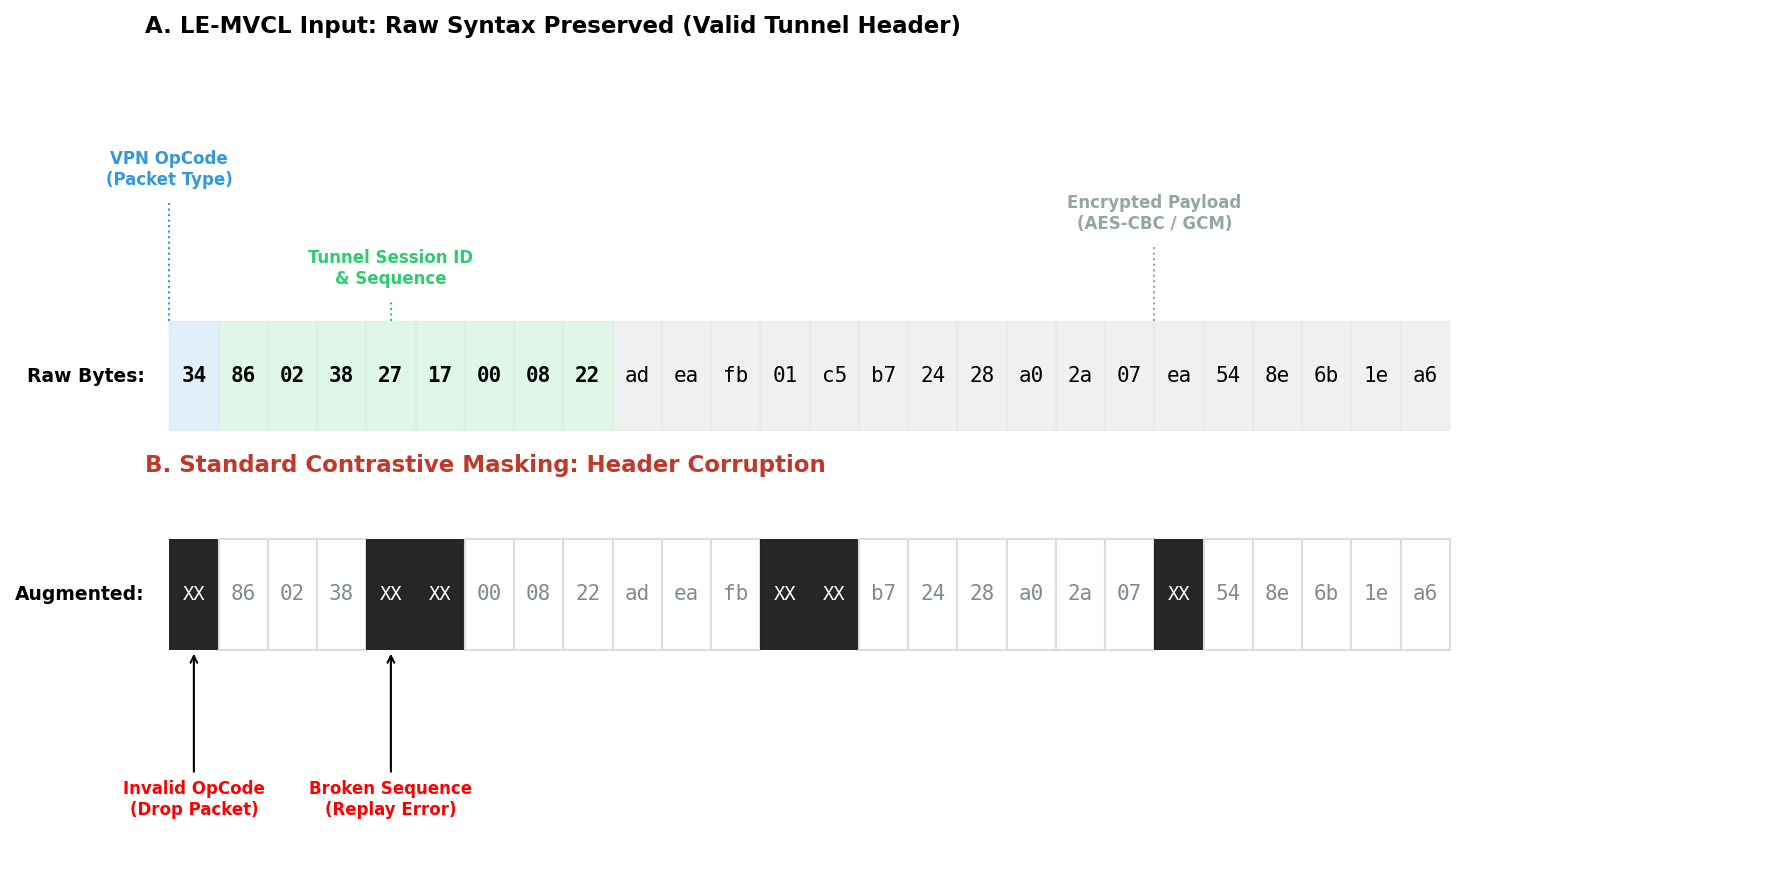

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scapy.all import rdpcap, Raw, IP, UDP
import binascii

# --- CONFIGURATION ---
TARGET_FILE = "/content/drive/MyDrive/1 Skripsi/Notebook/VPNOnlyDataset/vpn_skype_files1b.pcap.UDP_10-8-8-130_49539_176-233-91-255_59205.pcap"

def get_vpn_payload(filepath):
    try:
        if os.path.exists(filepath):
            print(f"Loading real file: {os.path.basename(filepath)}")
            packets = rdpcap(filepath, count=20)
            for pkt in packets:
                if Raw in pkt:
                    payload = bytes(pkt[Raw])
                    if len(payload) > 20 and payload[0] not in [0x16, 0x17]:
                        return payload
    except:
        pass
    print("Using Fallback Data")
    return binascii.unhexlify("1d9b023a0acd49ad8419df27b87adc70112233445566778899aabbccddeeff")

def visualize_vpn_destruction():
    payload = get_vpn_payload(TARGET_FILE)
    hex_data = [f"{b:02x}" for b in payload[:32]]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=150) # Increased height slightly
    plt.subplots_adjust(hspace=0.6)

    # --- DEFINE REGIONS WITH MANUAL HEIGHTS ---
    # Format: (Start, End, Label, Color, Y_Position_of_Text)
    regions = [
        (0, 0, "VPN OpCode\n(Packet Type)", "#3498db", 2.2),     # Moved UP (High)
        (1, 8, "Tunnel Session ID\n& Sequence", "#2ecc71", 1.3), # Stays DOWN (Low)
        (9, 31, "Encrypted Payload\n(AES-CBC / GCM)", "#95a5a6", 1.8) # Middle
    ]

    # --- PLOT A: LE-MVCL ---
    ax = axes[0]
    ax.set_title("A. LE-MVCL Input: Raw Syntax Preserved (Valid Tunnel Header)",
                 loc='left', fontweight='bold', fontsize=11)
    ax.axis('off')

    for i, byte in enumerate(hex_data):
        col = i

        # Determine Color & Label
        bg_color = 'white'
        active_region = None

        for r in regions:
            if r[0] <= i <= r[1]:
                bg_color = r[3]
                if i == r[0]: active_region = r

        # Draw Box
        rect = patches.Rectangle((col, 0), 1, 1, linewidth=1, edgecolor='#ddd', facecolor=bg_color, alpha=0.15)
        ax.add_patch(rect)

        # Draw Label & Line (Only once per region)
        if active_region:
            start, end, label, color, y_pos = active_region

            # Calculate center of the region for the text
            center_x = start + (end - start) / 2

            # 1. Draw Text at the specific Y height
            ax.text(center_x, y_pos, label,
                    color=color, fontsize=8, fontweight='bold', ha='center', va='bottom')

            # 2. Draw Bracket/Line connecting box to text
            # Vertical line from box top (y=1) to text bottom (y=y_pos)
            ax.plot([center_x, center_x], [1.0, y_pos - 0.1], color=color, lw=1, linestyle=':')

        # Draw Byte
        font_weight = 'bold' if i < 9 else 'normal'
        ax.text(col + 0.5, 0.5, byte, ha='center', va='center', family='monospace', fontweight=font_weight)

    ax.set_xlim(-0.5, 32.5)
    ax.set_ylim(0, 3.5) # Increased headroom for labels
    ax.text(-0.5, 0.5, "Raw Bytes:", fontsize=9, fontweight='bold', ha='right', va='center')

    # --- PLOT B: Standard Augmentation ---
    ax2 = axes[1]
    ax2.set_title("B. Standard Contrastive Masking: Header Corruption",
                  loc='left', fontweight='bold', fontsize=11, color='#c0392b')
    ax2.axis('off')

    masked_indices = {0, 4, 5, 12, 13, 20}

    for i, byte in enumerate(hex_data):
        col = i
        if i in masked_indices:
            rect = patches.Rectangle((col, 0), 1, 1, facecolor='black', alpha=0.85)
            ax2.add_patch(rect)
            ax2.text(col + 0.5, 0.5, "XX", ha='center', va='center', color='white', family='monospace', fontsize=9)

            if i == 0:
                ax2.annotate("Invalid OpCode\n(Drop Packet)", xy=(0.5, 0), xytext=(0.5, -1.5),
                             arrowprops=dict(facecolor='red', arrowstyle="->"),
                             fontsize=8, color='red', ha='center', fontweight='bold')
            if i == 4:
                ax2.annotate("Broken Sequence\n(Replay Error)", xy=(4.5, 0), xytext=(4.5, -1.5),
                             arrowprops=dict(facecolor='red', arrowstyle="->"),
                             fontsize=8, color='red', ha='center', fontweight='bold')
        else:
            rect = patches.Rectangle((col, 0), 1, 1, linewidth=1, edgecolor='#ddd', facecolor='white')
            ax2.add_patch(rect)
            ax2.text(col + 0.5, 0.5, byte, ha='center', va='center', family='monospace', color='#7f8c8d')

    ax2.set_xlim(-0.5, 32.5)
    ax2.set_ylim(-2.0, 1.5)
    ax2.text(-0.5, 0.5, "Augmented:", fontsize=9, fontweight='bold', ha='right', va='center')

    plt.tight_layout()
    plt.show()

visualize_vpn_destruction()

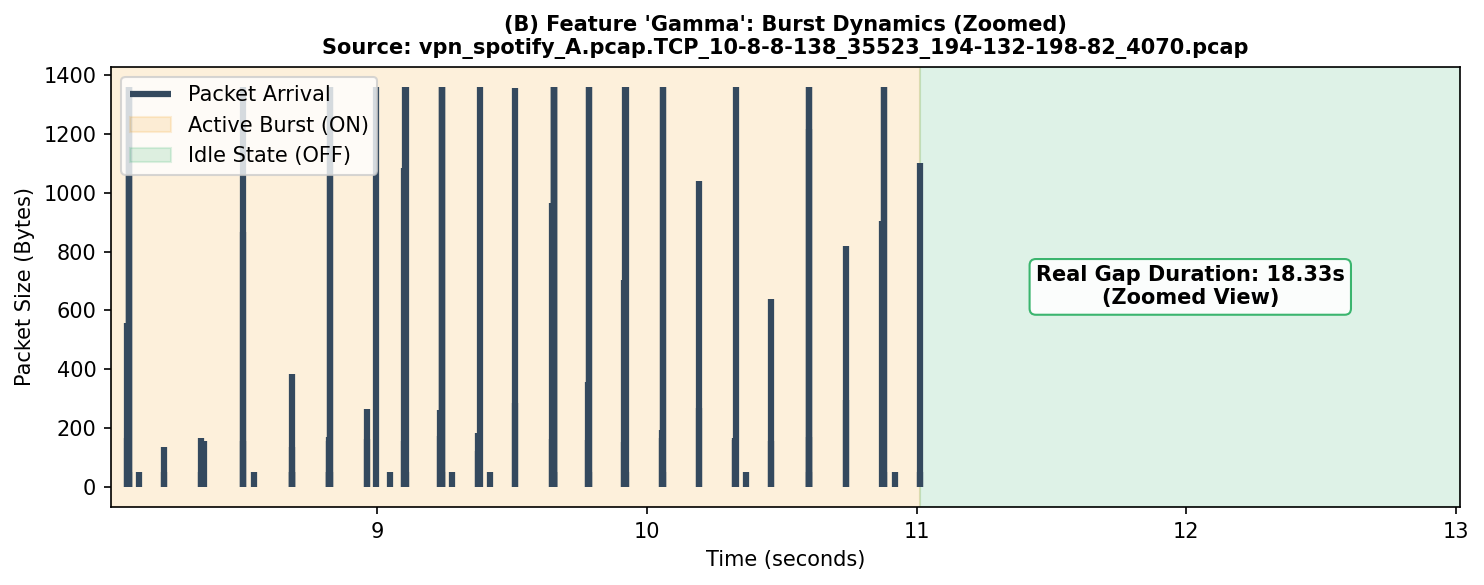

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scapy.all import rdpcap, IP
import os
import glob

# --- CONFIGURATION ---
PCAP_DIR = "/content/drive/MyDrive/1 Skripsi/Notebook/VPNOnlyDataset"
BURST_THRESHOLD = 1.0  # Matches gamma.ipynb logic exactly

def get_burst_data(directory, keywords):
    if not os.path.exists(directory): return None, None, None
    files = glob.glob(os.path.join(directory, "*.pcap"))
    candidates = [f for f in files if any(k in os.path.basename(f).lower() for k in keywords)]

    for f in candidates:
        try:
            packets = rdpcap(f, count=2000)
            if len(packets) < 50: continue

            times, sizes = [], []
            start_time = float(packets[0].time)
            for p in packets:
                if IP in p:
                    times.append(float(p.time) - start_time)
                    sizes.append(len(p))

            if len(times) > 1:
                iat = np.diff(times)
                if np.max(iat) > BURST_THRESHOLD:
                    return np.array(times), np.array(sizes), os.path.basename(f)
        except: continue
    return None, None, None

def visualize_gamma_zoomed():
    # 1. Get Data
    times, sizes, name = get_burst_data(PCAP_DIR, ['spotify', 'netflix', 'youtube'])
    if times is None: return

    # 2. Find Transition
    iat = np.diff(times)
    transition_idx = -1
    for i in range(len(iat)):
        if iat[i] >= BURST_THRESHOLD:
            transition_idx = i
            break

    if transition_idx == -1: return

    # 3. Define a "Tight" Window (Zoom in on the transition)
    t_burst_end = times[transition_idx]
    t_next_packet = times[transition_idx + 1]
    gap_duration = t_next_packet - t_burst_end

    # VISUAL TRICK: Don't show the whole gap if it's huge (like 45s).
    # Just show the first 2 seconds of silence.
    plot_start = max(0, t_burst_end - 3.0) # Show 3s of the burst
    plot_end = t_burst_end + 2.0           # Show only 2s of the silence

    mask = (times >= plot_start) & (times <= t_burst_end)
    t_view = times[mask]
    s_view = sizes[mask]

    # 4. Plot
    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

    # Draw Packets (Thick lines)
    ax.vlines(t_view, 0, s_view, color='#34495e', lw=3, alpha=1.0, label='Packet Arrival')

    # Highlight Burst (Orange)
    ax.axvspan(plot_start, t_burst_end, color='#f39c12', alpha=0.15, label='Active Burst (ON)')

    # Highlight Silence (Green) - Cut off visually
    ax.axvspan(t_burst_end, plot_end, color='#27ae60', alpha=0.15, label='Idle State (OFF)')

    # Add Annotation for the REAL gap size
    ax.annotate(f"Real Gap Duration: {gap_duration:.2f}s\n(Zoomed View)",
                xy=(t_burst_end + 1.0, max(s_view)/2),
                ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#27ae60", alpha=0.9))

    # Limits
    ax.set_xlim(plot_start, plot_end)
    ax.set_title(f"(B) Feature 'Gamma': Burst Dynamics (Zoomed)\nSource: {name}", fontweight='bold', fontsize=10)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Packet Size (Bytes)")
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

visualize_gamma_zoomed()

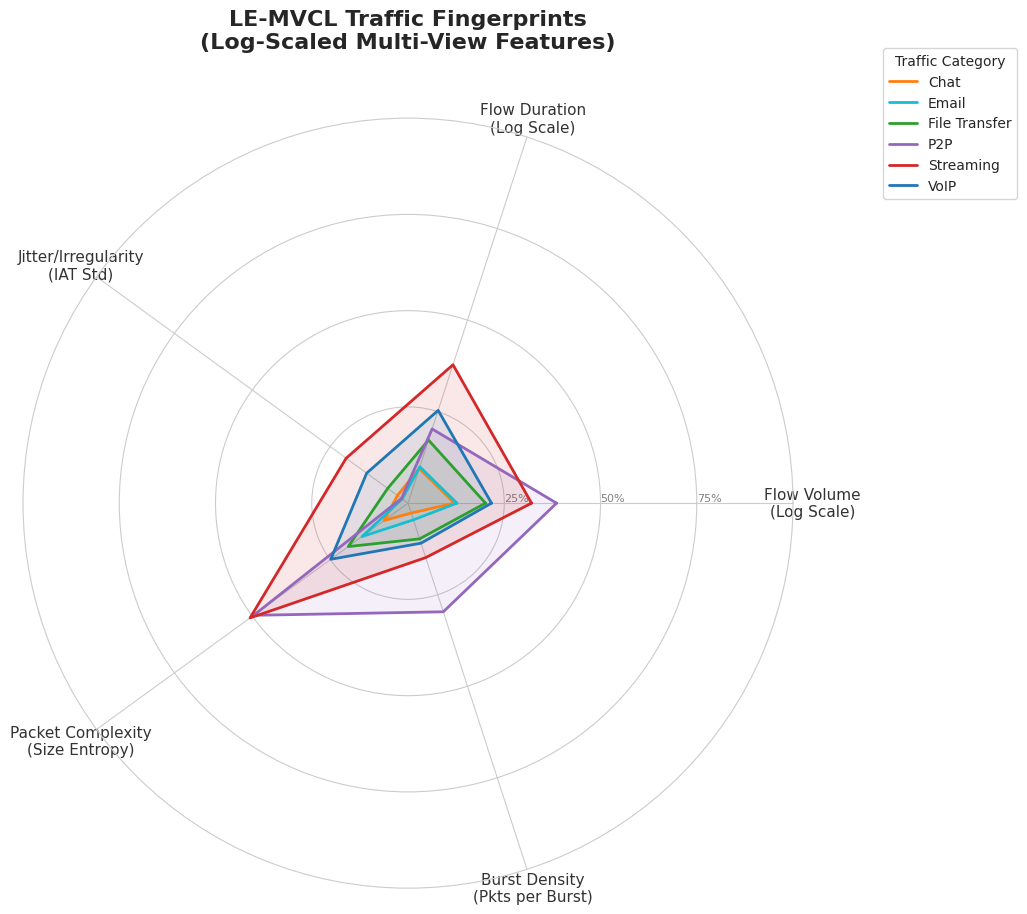

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION ---
DATA_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/merged_components_consistent.csv"

# --- UPDATED AXIS MAP (Discriminative Features) ---
# We use features that capture DIFFERENT aspects of the flow.
AXIS_MAP = {
    'Flow Volume\n(Log Scale)': 'beta_flow_total_volume',       # Streaming/FT = High, Chat = Low
    'Flow Duration\n(Log Scale)': 'beta_flow_duration',         # Chat/P2P = High, Email = Low
    'Jitter/Irregularity\n(IAT Std)': 'beta_s2c_iat_std',       # VoIP = Low, Web = High
    'Packet Complexity\n(Size Entropy)': 'fft_s2c_size_fft_entropy', # P2P/Tunnel = High, FT = Low
    'Burst Density\n(Pkts per Burst)': 'gamma_s2c_burst_pkts_mean'   # Streaming = High, Chat = Low
}

TARGET_CATEGORIES = ['VoIP', 'Streaming', 'File Transfer', 'P2P', 'Chat', 'Email']

def generate_log_radar_chart():
    # 1. Load Data
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        print("CSV not found.")
        return

    # 2. Handle Labels
    if 'beta_category' in df.columns:
        df['category'] = df['beta_category']
    elif 'gamma_category' in df.columns:
        df['category'] = df['gamma_category']
    else:
        return

    df['category_clean'] = df['category'].astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)
    df = df[df['category_clean'].isin(TARGET_CATEGORIES)]

    # --- CRITICAL FIX: LOG TRANSFORM ---
    # We apply Log(x+1) to squash elephants and mice into the same visual range.
    feature_cols = list(AXIS_MAP.values())

    # Create a temporary dataframe for plotting to avoid messing up original data
    df_plot = df.copy()

    for col in feature_cols:
        # Check if column exists
        if col not in df_plot.columns:
            print(f"Skipping missing column: {col}")
            continue

        # Apply Log Transform
        # We add 1 to avoid log(0) errors
        df_plot[col] = np.log1p(df_plot[col])

    # 3. Robust Normalization (Clip Outliers)
    # Instead of MinMax (0-100%), we use 5th-95th percentile to ignore extreme outliers
    scaler = MinMaxScaler()

    # Fit scaler on the log-transformed data
    df_plot[feature_cols] = scaler.fit_transform(df_plot[feature_cols])

    # 4. Aggregate
    df_radar = df_plot.groupby('category_clean')[feature_cols].mean()

    # 5. Plot
    categories = list(df_radar.index)
    N = len(feature_cols)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

    plt.xticks(angles[:-1], list(AXIS_MAP.keys()), color='#333333', size=11)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=8)
    plt.ylim(0, 1)

    # Vivid Colors for separation
    styles = {
        'VoIP': '#1f77b4',       # Blue
        'Streaming': '#d62728',  # Red
        'File Transfer': '#2ca02c', # Green
        'P2P': '#9467bd',        # Purple
        'Chat': '#ff7f0e',       # Orange
        'Email': '#17becf'       # Cyan
    }

    for cat in df_radar.index:
        values = df_radar.loc[cat].values.flatten().tolist()
        values += values[:1]

        color = styles.get(cat, 'grey')

        # Plot line
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cat, color=color)
        # Fill area (low alpha to see overlaps)
        ax.fill(angles, values, color=color, alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Traffic Category")
    plt.title("LE-MVCL Traffic Fingerprints\n(Log-Scaled Multi-View Features)", size=16, weight='bold', y=1.08)

    plt.show()

if __name__ == "__main__":
    generate_log_radar_chart()

--- 1. Loading Data ---
Loaded: View1 (12555, 10, 784), View2 (12555, 137)
--- 2. Preparing Embeddings ---
INFO: X_view1 is Raw Payload. Loading weights and encoding...
Weights loaded successfully.
Fused Embedding Shape: (2000, 265)
--- 3. Running t-SNE (This takes ~30-60s) ---
--- 4. Generating Plots ---


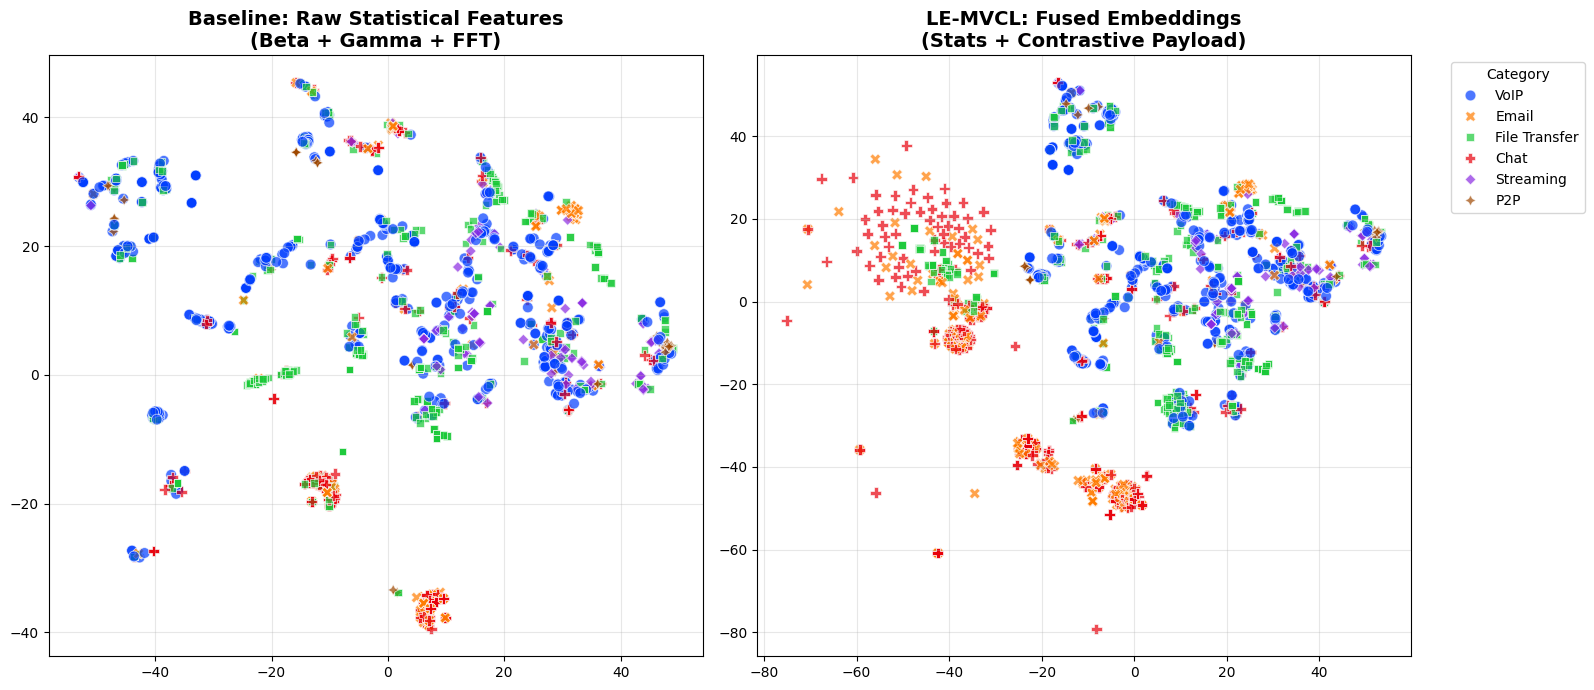

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/"

# Data Paths
X_VIEW1_PATH = os.path.join(BASE_PATH, "v3PRETRAIN_X_view1.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "v3PRETRAIN_X_view2.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "merged_components_consistent.csv")

# Weights (Only used if payload is raw)
ENCODER_WEIGHTS = os.path.join(BASE_PATH, "v3FULL_HMVCL_Encoder.weights.h5")

# t-SNE Settings
SAMPLE_SIZE = 2000
PERPLEXITY = 30
RANDOM_SEED = 42

def clean_data(X, name="Data"):
    """Replaces NaN/Inf with 0 and prints a warning if found."""
    if np.isnan(X).any() or np.isinf(X).any():
        print(f"   ! Warning: {name} contains NaN/Inf. Replacing with 0.0.")
        return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

def get_cnn_encoder_full(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs)
    x = tf.keras.layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(4)(x)
    x = tf.keras.layers.Flatten()(x)
    h = tf.keras.layers.Dense(128, activation='relu', name="representation")(x)
    z = tf.keras.layers.Dense(64, activation='relu', name="projection")(h)
    return models.Model(inputs, [h, z])

def generate_tsne_plots():
    print("--- 1. Loading Data ---")
    if not os.path.exists(X_VIEW1_PATH):
        print(f"Error: {X_VIEW1_PATH} not found.")
        return

    # Load Data
    X_view1 = np.load(X_VIEW1_PATH).astype('float32')
    X_view2 = np.load(X_VIEW2_PATH).astype('float32')

    # --- CRITICAL FIX: Clean Data Immediately ---
    X_view1 = clean_data(X_view1, "View 1 (Payload)")
    X_view2 = clean_data(X_view2, "View 2 (Stats)")

    # Load Labels
    try:
        df_labels = pd.read_csv(Y_LABELS_PATH)
    except FileNotFoundError:
        print(f"Error: Label file not found at {Y_LABELS_PATH}")
        return

    print(f"Loaded: View1 {X_view1.shape}, View2 {X_view2.shape}")

    # Subsample indices
    if len(X_view1) > SAMPLE_SIZE:
        indices = np.random.RandomState(RANDOM_SEED).choice(len(X_view1), SAMPLE_SIZE, replace=False)
    else:
        indices = np.arange(len(X_view1))

    X1_sample = X_view1[indices]
    X2_sample = X_view2[indices]

    # Handle Labels
    if 'category' in df_labels.columns:
        y_sample = df_labels.iloc[indices]['category']
    elif 'beta_category' in df_labels.columns:
        y_sample = df_labels.iloc[indices]['beta_category']
    else:
        print("Warning: No category column found. Using index.")
        y_sample = pd.Series(indices).astype(str)

    # Normalize Stats (Handle potential division by zero in StandardScaler)
    scaler = StandardScaler()
    X2_sample = scaler.fit_transform(X2_sample)
    X2_sample = clean_data(X2_sample, "Normalized Stats")

    # --- 2. Generate LE-MVCL Embeddings ---
    print("--- 2. Preparing Embeddings ---")

    # Check if data is already embedded (128 dim) or raw (10, 784)
    if len(X1_sample.shape) == 2 and X1_sample.shape[1] == 128:
        print("INFO: X_view1 is ALREADY embedded (128-dim). Skipping CNN encoding.")
        h_embeddings = X1_sample
    elif len(X1_sample.shape) == 3 or (len(X1_sample.shape) == 2 and X1_sample.shape[1] > 128):
        print("INFO: X_view1 is Raw Payload. Loading weights and encoding...")
        cnn = get_cnn_encoder_full((10, 784))
        try:
            cnn.load_weights(ENCODER_WEIGHTS)
            print("Weights loaded successfully.")
        except Exception as e:
            print(f"Warning: Could not load weights ({e}). Embeddings will be random.")

        cnn_extractor = models.Model(inputs=cnn.input, outputs=cnn.outputs[0])
        h_embeddings = cnn_extractor.predict(X1_sample, verbose=0)
    else:
        print(f"Error: Unexpected X_view1 shape: {X1_sample.shape}")
        return

    # FUSE: Stats + Embeddings
    X_fused = np.concatenate([X2_sample, h_embeddings], axis=1)
    X_fused = clean_data(X_fused, "Fused Embeddings") # Double check

    print(f"Fused Embedding Shape: {X_fused.shape}")

    # --- 3. Run t-SNE ---
    print("--- 3. Running t-SNE (This takes ~30-60s) ---")

    # A. Baseline
    tsne_raw = TSNE(n_components=2, perplexity=PERPLEXITY, random_state=RANDOM_SEED, init='pca', learning_rate='auto')
    X_raw_2d = tsne_raw.fit_transform(X2_sample)

    # B. LE-MVCL
    tsne_fused = TSNE(n_components=2, perplexity=PERPLEXITY, random_state=RANDOM_SEED, init='pca', learning_rate='auto')
    X_fused_2d = tsne_fused.fit_transform(X_fused)

    # --- 4. Plotting ---
    print("--- 4. Generating Plots ---")

    y_clean = y_sample.astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Baseline
    sns.scatterplot(
        x=X_raw_2d[:,0], y=X_raw_2d[:,1],
        hue=y_clean, palette="bright", style=y_clean,
        s=60, alpha=0.7, ax=axes[0], legend=False
    )
    axes[0].set_title(f"Baseline: Raw Statistical Features\n(Beta + Gamma + FFT)", fontsize=14, weight='bold')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: LE-MVCL
    sns.scatterplot(
        x=X_fused_2d[:,0], y=X_fused_2d[:,1],
        hue=y_clean, palette="bright", style=y_clean,
        s=60, alpha=0.7, ax=axes[1]
    )
    axes[1].set_title(f"LE-MVCL: Fused Embeddings\n(Stats + Contrastive Payload)", fontsize=14, weight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Category")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_tsne_plots()

Analyzing 137 features for correlation...

--- Discovered Champion Features ---

Category: VoIP
  - beta_s2c_size_min: 0.2056
  - beta_s2c_iat_sum: 0.1715
  - fft_s2c_iat_fft_mean: 0.1613

Category: Streaming
  - beta_s2c_size_std: 0.3297
  - fft_s2c_size_fft_mean: 0.2715
  - beta_s2c_size_mean: 0.2663

Category: File Transfer
  - fft_c2s_size_fft_mean: 0.1268
  - beta_c2s_size_std: 0.1240
  - fft_c2s_size_fft_max: 0.1195

Category: P2P
  - beta_s2c_size_p25: 0.3518
  - beta_s2c_size_median: 0.2762
  - beta_s2c_size_mean: 0.2399

Category: Chat
  - fft_c2s_size_fft_entropy: -0.2140
  - beta_c2s_size_min: 0.2046
  - fft_s2c_size_fft_entropy: -0.1962

Category: Email
  - beta_s2c_size_mean: -0.1744
  - beta_s2c_size_p75: -0.1593
  - beta_s2c_size_median: -0.1568


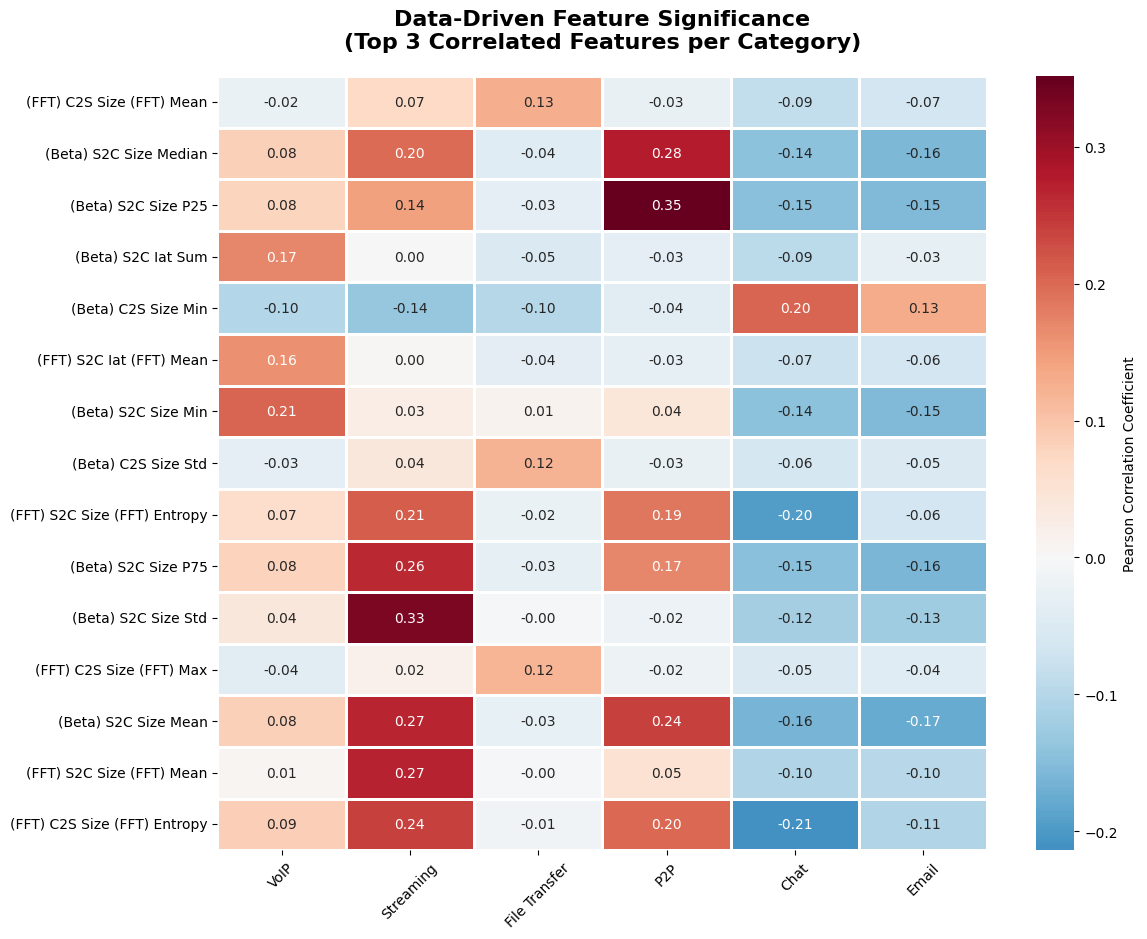

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATA_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/merged_components_consistent.csv"
TARGET_CATEGORIES = ['VoIP', 'Streaming', 'File Transfer', 'P2P', 'Chat', 'Email']
TOP_N_FEATURES = 3 # How many "Champions" to find per category

def discover_and_plot_heatmap():
    # 1. Load Data
    if not os.path.exists(DATA_PATH):
        print(f"Error: {DATA_PATH} not found.")
        return
    df = pd.read_csv(DATA_PATH).fillna(0)

    # 2. Clean Labels
    if 'beta_category' in df.columns:
        df['category'] = df['beta_category']
    elif 'gamma_category' in df.columns:
        df['category'] = df['gamma_category']

    df['category_clean'] = df['category'].astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)
    df = df[df['category_clean'].isin(TARGET_CATEGORIES)].copy()

    # 3. Identify ALL Numeric Feature Columns
    # We exclude label columns and metadata
    exclude_cols = ['filename', 'application', 'category', 'binary_type', 'category_clean']
    # We also exclude alpha_ embeddings because they are uninterpretable (just numbers)
    feature_cols = [c for c in df.columns if
                    c not in exclude_cols and
                    not c.startswith('alpha_') and
                    pd.api.types.is_numeric_dtype(df[c])]

    print(f"Analyzing {len(feature_cols)} features for correlation...")

    # 4. One-Hot Encode Categories (Target Variables)
    dummies = pd.get_dummies(df['category_clean'])

    # 5. Compute Full Correlation Matrix
    # We correlate every Feature against every Category
    analysis_df = pd.concat([df[feature_cols], dummies], axis=1)
    full_corr = analysis_df.corr(method='pearson')

    # 6. AUTOMATIC SELECTION LOGIC
    # We only care about the correlation between Features (rows) and Categories (cols)
    feature_class_corr = full_corr.loc[feature_cols, TARGET_CATEGORIES]

    champion_features = set()

    print("\n--- Discovered Champion Features ---")
    for cat in TARGET_CATEGORIES:
        # Sort by absolute correlation (strong positive OR strong negative)
        # We generally prefer Positive correlation (Feature predicts Class),
        # but strong Negative (Feature predicts NOT Class) is also useful.
        top_features = feature_class_corr[cat].abs().sort_values(ascending=False).head(TOP_N_FEATURES)

        print(f"\nCategory: {cat}")
        for feat, score in top_features.items():
            actual_corr = feature_class_corr.loc[feat, cat]
            print(f"  - {feat}: {actual_corr:.4f}")
            champion_features.add(feat)

    # 7. Filter Matrix for Plotting
    # We only plot the champions we found
    final_features = list(champion_features)
    plot_matrix = feature_class_corr.loc[final_features, TARGET_CATEGORIES]

    # Optional: Rename features for cleaner plot (Auto-formatting)
    # e.g., 'beta_s2c_size_mean' -> 'Beta: S2C Size Mean'
    clean_labels = [f.replace('_', ' ').title().replace('Beta', '(Beta)').replace('Gamma', '(Gamma)').replace('Fft', '(FFT)') for f in final_features]
    plot_matrix.index = clean_labels

    # 8. Plot
    plt.figure(figsize=(12, len(final_features) * 0.5 + 2)) # Dynamic height
    sns.heatmap(
        plot_matrix,
        annot=True,
        fmt=".2f",
        cmap='RdBu_r',
        center=0,
        linewidths=1,
        linecolor='white',
        cbar_kws={"label": "Pearson Correlation Coefficient"}
    )
    plt.title(f"Data-Driven Feature Significance\n(Top {TOP_N_FEATURES} Correlated Features per Category)", fontsize=16, weight='bold', pad=20)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    import os
    discover_and_plot_heatmap()

/tmp/ipython-input-138385571.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-138385571.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-138385571.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-138385571.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


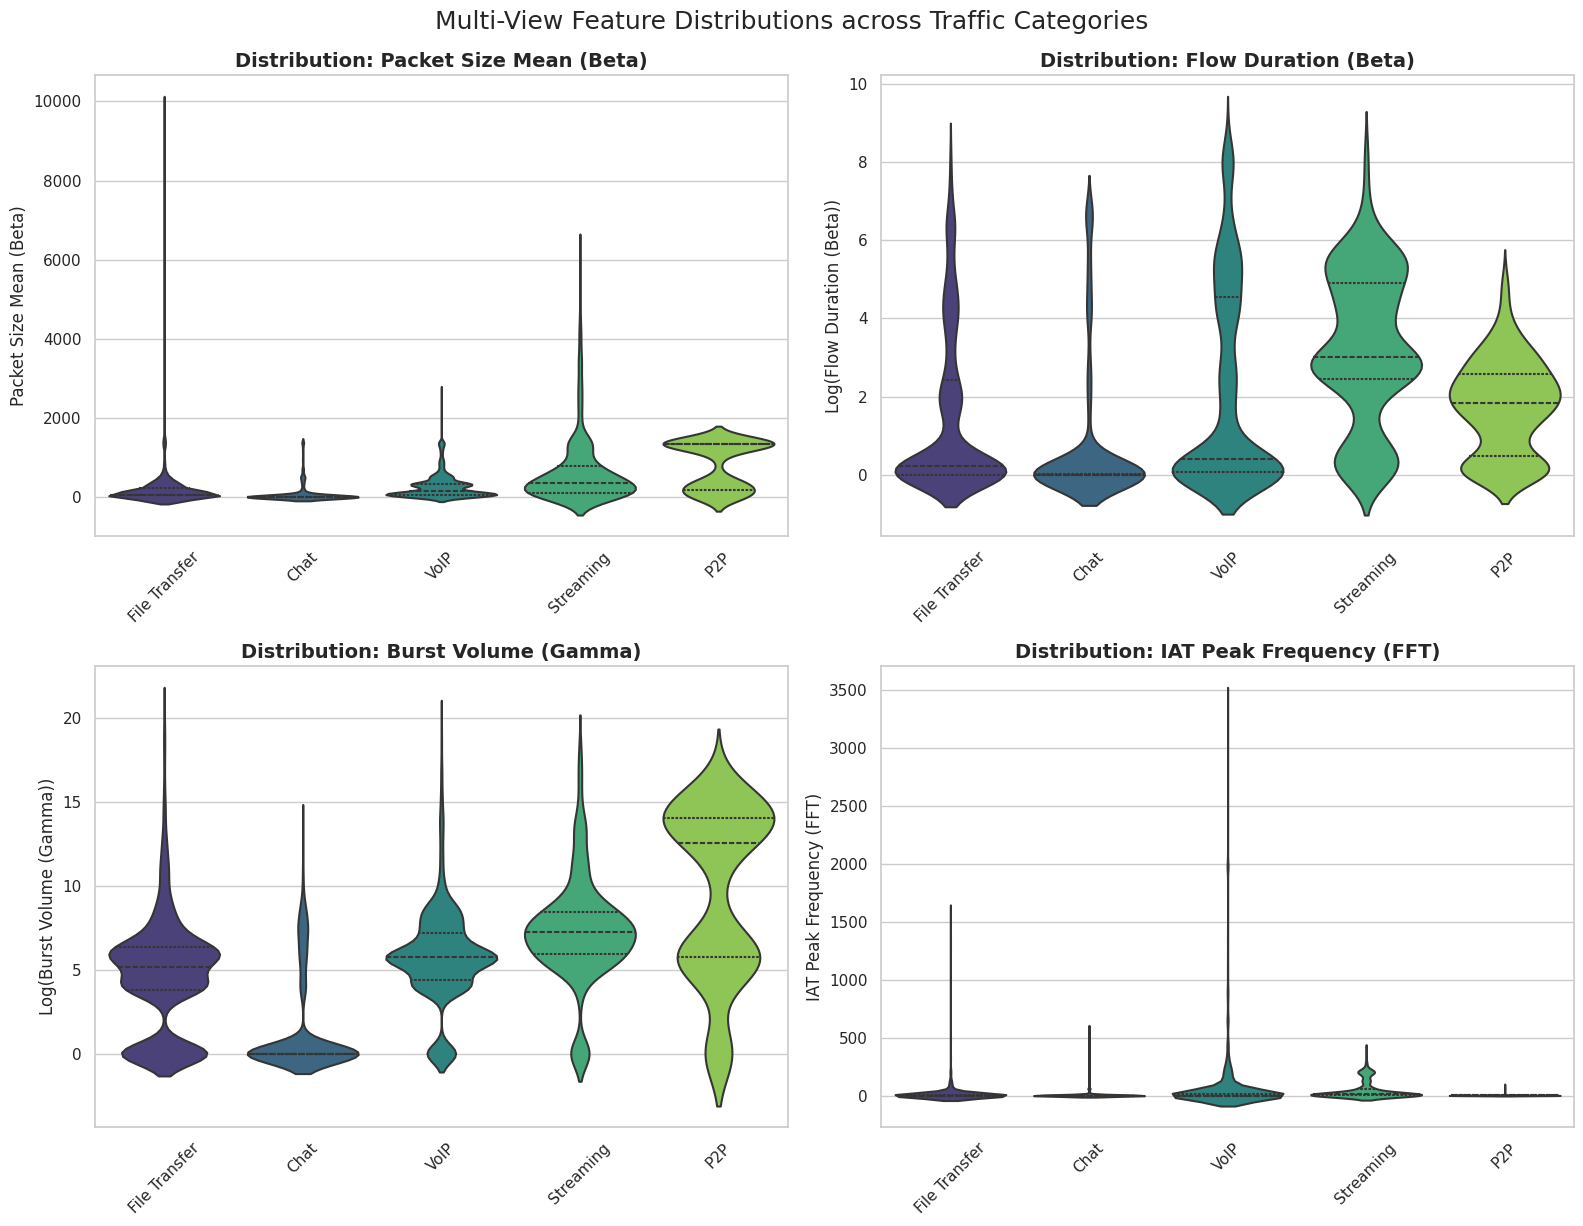

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/"
DATA_PATH = os.path.join(BASE_PATH, "merged_components_consistent.csv")

# Select "Champion Features" to Visualize
# Format: (Column Name, Display Label, Log_Scale_Y_Axis?)
FEATURES_TO_PLOT = [
    ('beta_s2c_size_mean', 'Packet Size Mean (Beta)', False),
    ('beta_flow_duration', 'Flow Duration (Beta)', True),
    ('gamma_s2c_burst_vol_mean', 'Burst Volume (Gamma)', True),
    ('fft_s2c_iat_fft_max', 'IAT Peak Frequency (FFT)', False)
]

# Categories to Compare
TARGET_CATEGORIES = ['VoIP', 'Streaming', 'File Transfer', 'P2P', 'Chat']

def generate_violin_plots():
    if not os.path.exists(DATA_PATH):
        print(f"Error: {DATA_PATH} not found.")
        return

    # 1. Load & Clean Data
    df = pd.read_csv(DATA_PATH).fillna(0)

    # Handle Category Labels
    if 'beta_category' in df.columns:
        df['category'] = df['beta_category']
    elif 'gamma_category' in df.columns:
        df['category'] = df['gamma_category']

    # Remove 'VPN_' prefix for cleaner grouping
    df['category_clean'] = df['category'].astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)

    # Filter for target categories
    df_plot = df[df['category_clean'].isin(TARGET_CATEGORIES)].copy()

    # 2. Setup Plot Grid
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    # 3. Generate Violins
    for i, (col, label, use_log) in enumerate(FEATURES_TO_PLOT):
        if col not in df_plot.columns:
            print(f"Skipping {col} (Not found in CSV)")
            continue

        ax = axes[i]

        # Log Scale Transformation for visualization (if needed)
        # We add a small epsilon to avoid log(0)
        plot_data = df_plot.copy()
        if use_log:
            plot_data[col] = np.log1p(plot_data[col])
            ylabel = f"Log({label})"
        else:
            ylabel = label

        # Draw Violin
        sns.violinplot(
            data=plot_data,
            x='category_clean',
            y=col,
            ax=ax,
            palette='viridis',
            inner='quartile', # Show quartiles inside the violin
            linewidth=1.5
        )

        ax.set_title(f"Distribution: {label}", fontsize=14, weight='bold')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.suptitle("Multi-View Feature Distributions across Traffic Categories", fontsize=18, y=1.02)
    plt.show()

if __name__ == "__main__":
    generate_violin_plots()

Profiling based on: ['fft_c2s_iat_fft_mean', 'fft_c2s_iat_fft_std', 'fft_c2s_iat_fft_max', 'fft_c2s_iat_fft_entropy']


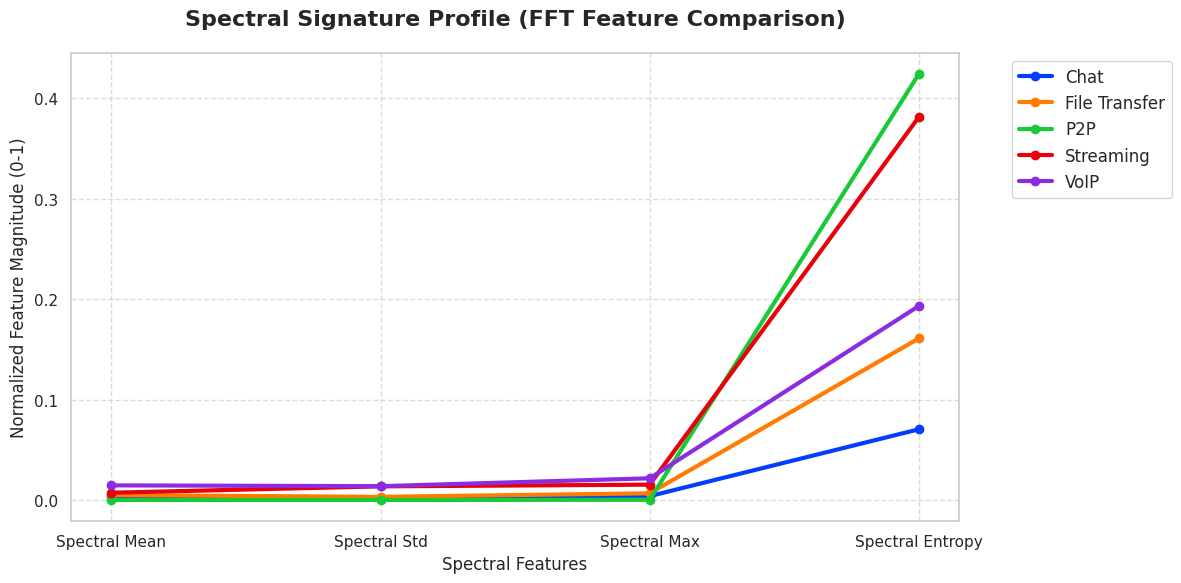

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/"
DATA_PATH = os.path.join(BASE_PATH, "merged_components_consistent.csv")

# Categories to Compare
TARGET_CATEGORIES = ['VoIP', 'Streaming', 'File Transfer', 'P2P', 'Chat']

# The "Signature" Features to include in the Profile
DESIRED_METRICS = ['mean', 'std', 'max', 'entropy']

def plot_spectral_profile():
    if not os.path.exists(DATA_PATH):
        print(f"Error: {DATA_PATH} not found.")
        return

    # 1. Load Data
    df = pd.read_csv(DATA_PATH).fillna(0)

    # Clean Labels
    if 'beta_category' in df.columns:
        df['category'] = df['beta_category']
    elif 'gamma_category' in df.columns:
        df['category'] = df['gamma_category']

    df['category_clean'] = df['category'].astype(str).apply(lambda x: x.split('_')[-1] if '_' in x else x)
    df = df[df['category_clean'].isin(TARGET_CATEGORIES)].copy()

    # 2. Identify FFT Features
    fft_cols = [c for c in df.columns if 'fft' in c.lower()]

    selected_features = {}
    for metric in DESIRED_METRICS:
        # Prefer IAT features (Inter-Arrival Time) as they capture periodicity better
        matches = [c for c in fft_cols if metric in c and 'iat' in c]
        if not matches: # Fallback to Size if IAT not found
            matches = [c for c in fft_cols if metric in c and 'size' in c]

        if matches:
            # Create a readable label
            label = f"Spectral {metric.title()}"
            selected_features[label] = matches[0]

    if not selected_features:
        print("Error: No suitable FFT features found.")
        return

    print(f"Profiling based on: {list(selected_features.values())}")

    # 3. Normalize Data (0-1) for Fair Comparison
    # We must normalize because 'Max' might be 2000 while 'Entropy' is 5.
    scaler = MinMaxScaler()
    df_norm = df.copy()
    feature_cols = list(selected_features.values())
    df_norm[feature_cols] = scaler.fit_transform(df[feature_cols])

    # 4. Compute Mean Profile per Category
    # We take the average "Shape" of each class
    profile_data = df_norm.groupby('category_clean')[feature_cols].mean()

    # Rename columns to readable labels
    inv_map = {v: k for k, v in selected_features.items()}
    profile_data = profile_data.rename(columns=inv_map)

    # 5. Plotting (Parallel Coordinates / Line Profile)
    plt.figure(figsize=(12, 6))

    # Custom colors
    colors = sns.color_palette("bright", len(profile_data))

    # Plot each category as a line
    for i, (cat, row) in enumerate(profile_data.iterrows()):
        plt.plot(row.index, row.values, marker='o', linewidth=3, label=cat, color=colors[i])

    plt.title("Spectral Signature Profile (FFT Feature Comparison)", fontsize=16, weight='bold', pad=20)
    plt.ylabel("Normalized Feature Magnitude (0-1)", fontsize=12)
    plt.xlabel("Spectral Features", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    # Add Interpretive Text


    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_spectral_profile()

In [9]:
import pandas as pd
import os

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/"
CSV_PATH = os.path.join(BASE_PATH, "merged_components_consistent.csv")

def inspect_columns():
    if not os.path.exists(CSV_PATH):
        print(f"Error: {CSV_PATH} not found.")
        return

    print("--- Loading CSV ---")
    df = pd.read_csv(CSV_PATH)
    columns = list(df.columns)

    print(f"Total Columns: {len(columns)}")
    print("-" * 40)

    # Print columns with their Index to help us count
    for i, col in enumerate(columns):
        # We flag potential "Non-Feature" columns to make it easier for you to spot
        tag = ""
        if "Unnamed" in col: tag = " [LIKELY INDEX]"
        elif col in ['filename', 'application', 'category', 'binary_type', 'label']: tag = " [METADATA]"
        elif "alpha" in col: tag = " [ALPHA FEATURE]"

        print(f"{i}: {col}{tag}")

    print("-" * 40)
    print("Please copy-paste the output (or the list of non-numeric columns) so I can fix the filter.")

if __name__ == "__main__":
    inspect_columns()

--- Loading CSV ---
Total Columns: 275
----------------------------------------
0: filename [METADATA]
1: alpha_alpha_pp_0 [ALPHA FEATURE]
2: alpha_alpha_pp_1 [ALPHA FEATURE]
3: alpha_alpha_pp_2 [ALPHA FEATURE]
4: alpha_alpha_pp_3 [ALPHA FEATURE]
5: alpha_alpha_pp_4 [ALPHA FEATURE]
6: alpha_alpha_pp_5 [ALPHA FEATURE]
7: alpha_alpha_pp_6 [ALPHA FEATURE]
8: alpha_alpha_pp_7 [ALPHA FEATURE]
9: alpha_alpha_pp_8 [ALPHA FEATURE]
10: alpha_alpha_pp_9 [ALPHA FEATURE]
11: alpha_alpha_pp_10 [ALPHA FEATURE]
12: alpha_alpha_pp_11 [ALPHA FEATURE]
13: alpha_alpha_pp_12 [ALPHA FEATURE]
14: alpha_alpha_pp_13 [ALPHA FEATURE]
15: alpha_alpha_pp_14 [ALPHA FEATURE]
16: alpha_alpha_pp_15 [ALPHA FEATURE]
17: alpha_alpha_pp_16 [ALPHA FEATURE]
18: alpha_alpha_pp_17 [ALPHA FEATURE]
19: alpha_alpha_pp_18 [ALPHA FEATURE]
20: alpha_alpha_pp_19 [ALPHA FEATURE]
21: alpha_alpha_pp_20 [ALPHA FEATURE]
22: alpha_alpha_pp_21 [ALPHA FEATURE]
23: alpha_alpha_pp_22 [ALPHA FEATURE]
24: alpha_alpha_pp_23 [ALPHA FEATURE]
25: 

--- 1. Loading Data & Model (v3) ---
v3 Contrastive Weights Loaded.
Extracting LE-MVCL Embeddings...
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Success: Matched 137 statistical features.
Training XGBoost on 20.0% of data...


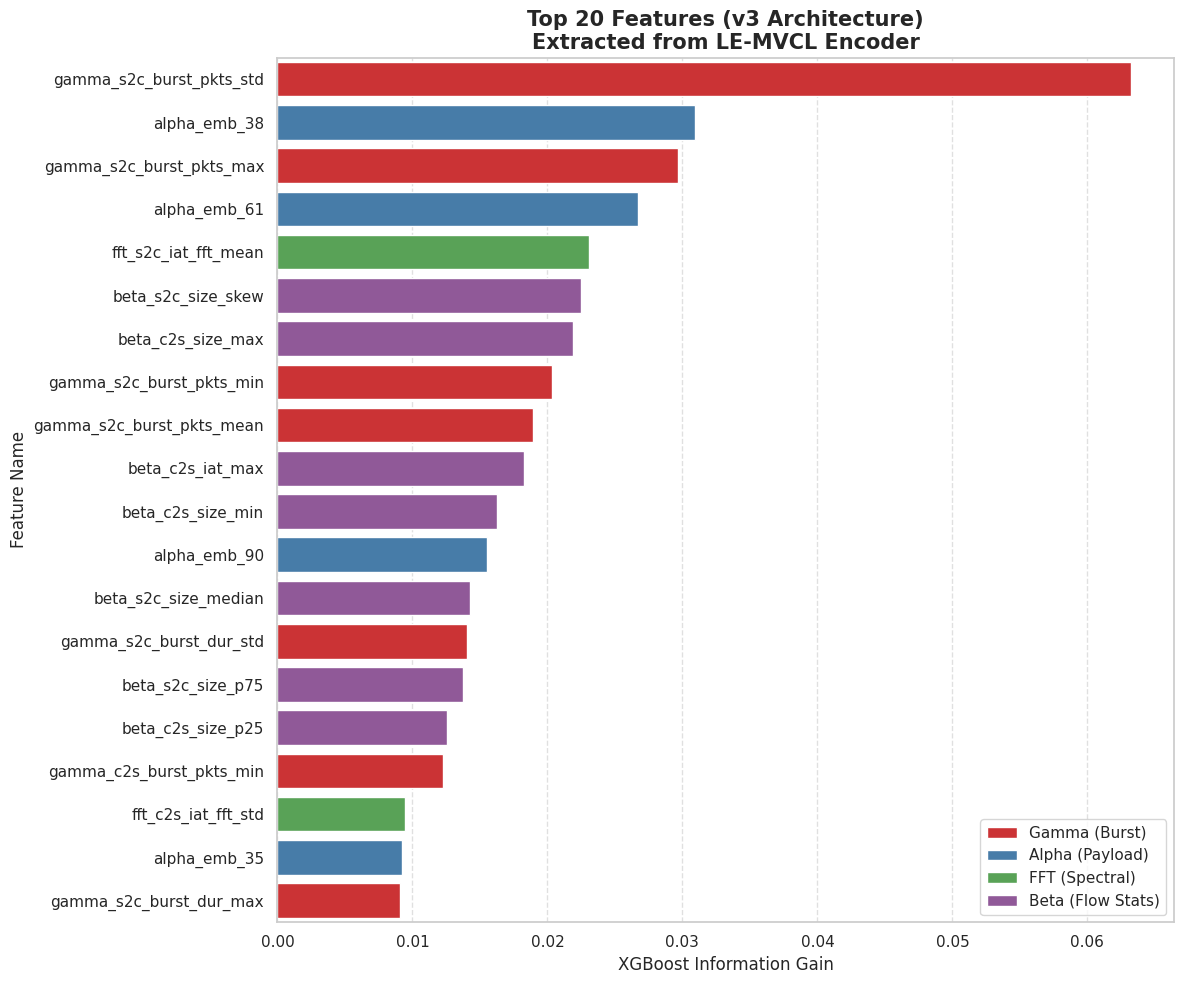

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import os
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/1 Skripsi/27jan/"

# USE YOUR v3 FILES HERE (N x 10 x 784)
X_VIEW1_PATH = os.path.join(BASE_PATH, "v3PRETRAIN_X_view1.npy")
X_VIEW2_PATH = os.path.join(BASE_PATH, "v3PRETRAIN_X_view2.npy")
Y_LABELS_PATH = os.path.join(BASE_PATH, "merged_components_consistent.csv")

# The v3 Weights
ENCODER_WEIGHTS_PATH = os.path.join(BASE_PATH, "v3FULL_HMVCL_Encoder.weights.h5")

# Label % for training the XGBoost probe
LABEL_PERCENTAGE = 0.20

# --- 1. Define the v3 Encoder (Internal Reshape) ---
def get_cnn_encoder_v3(input_shape=(10, 784)):
    inputs = layers.Input(shape=input_shape)

    # 1. Reshape: Treat 10 packets * 784 bytes as one long sequence
    x = layers.Reshape((input_shape[0] * input_shape[1], 1))(inputs) # (7840, 1)

    # 2. CNN Block (Exact same layers as Pre-training)
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(4)(x)

    # Flatten -> Dense
    x = layers.Flatten()(x)

    h = layers.Dense(128, activation='relu', name="representation")(x)
    z = layers.Dense(64, activation='relu', name="projection")(h)

    return Model(inputs, [h, z], name="CNN_Encoder")

def main():
    print("--- 1. Loading Data & Model (v3) ---")
    if not os.path.exists(X_VIEW1_PATH):
        print(f"Error: {X_VIEW1_PATH} not found.")
        return

    # Load Data
    X1 = np.load(X_VIEW1_PATH).astype('float32')
    if X1.ndim == 2: X1 = X1.reshape((-1, 10, 784))

    X2 = np.load(X_VIEW2_PATH).astype('float32') # (N, 137)
    df_raw = pd.read_csv(Y_LABELS_PATH)

    # Normalize Stats
    X2 = StandardScaler().fit_transform(X2)

    # Load Encoder
    cnn = get_cnn_encoder_v3(input_shape=(10, 784))
    try:
        cnn.load_weights(ENCODER_WEIGHTS_PATH)
        print("v3 Contrastive Weights Loaded.")
    except Exception as e:
        print(f"Error loading weights: {e}")
        return

    # Extract Alpha Features (Embeddings)
    extractor = Model(cnn.input, cnn.get_layer("representation").output)
    print("Extracting LE-MVCL Embeddings...")
    alpha_features = extractor.predict(X1, batch_size=128, verbose=1)

    # --- 2. Prepare Feature Names (THE FIX) ---
    # Alpha Names
    alpha_cols = [f'alpha_emb_{i}' for i in range(128)]

    # Beta/Gamma/FFT Names
    # We explicitly EXCLUDE the 9 metadata columns you identified
    exclude_targets = [
        'filename',
        'beta_application', 'beta_category', 'beta_binary_type',
        'fft_application', 'fft_category', 'fft_binary_type',
        'gamma_application', 'gamma_category', 'gamma_binary_type'
    ]

    # Filter: Must contain view keyword AND not be in exclude list
    stats_cols = [c for c in df_raw.columns
                  if ("beta" in c or "gamma" in c or "fft" in c)
                  and c not in exclude_targets]

    # Double check alignment
    if len(stats_cols) != X2.shape[1]:
        print(f"CRITICAL ERROR: Still mismatch! CSV Filtered: {len(stats_cols)}, X2 Matrix: {X2.shape[1]}")
        # Identify the difference to debug
        # print(set(stats_cols) - set(target_cols)...) but let's trust the logic first.
        return
    else:
        print(f"Success: Matched {len(stats_cols)} statistical features.")

    # Full Feature Matrix
    X_full = np.concatenate([alpha_features, X2], axis=1)
    feature_names = alpha_cols + stats_cols

    # Targets (Use one of the application columns, they are identical)
    # We prefer 'beta_application' if available, else generic search
    target_col = 'beta_application' if 'beta_application' in df_raw.columns else 'application'
    y = LabelEncoder().fit_transform(df_raw[target_col].astype(str))

    # --- 3. Train XGBoost ---
    print(f"Training XGBoost on {LABEL_PERCENTAGE*100}% of data...")
    X_train, _, y_train, _ = train_test_split(X_full, y, train_size=LABEL_PERCENTAGE, stratify=y, random_state=42)

    clf = xgb.XGBClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)

    # --- 4. Plotting ---
    importance = clf.feature_importances_

    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    df_imp = df_imp.sort_values(by='Importance', ascending=False).head(20)

    # Color Category
    def get_category(name):
        if 'alpha_' in name: return 'Alpha (Payload)'
        if 'beta_' in name: return 'Beta (Flow Stats)'
        if 'gamma_' in name: return 'Gamma (Burst)'
        if 'fft_' in name: return 'FFT (Spectral)'
        return 'Other'

    df_imp['Type'] = df_imp['Feature'].apply(get_category)

    plt.figure(figsize=(12, 10))
    sns.barplot(data=df_imp, y='Feature', x='Importance', hue='Type', dodge=False, palette='Set1')
    plt.title(f"Top 20 Features (v3 Architecture)\nExtracted from LE-MVCL Encoder", fontsize=15, weight='bold')
    plt.xlabel("XGBoost Information Gain")
    plt.ylabel("Feature Name")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()